# 🏥 MediAssist AI — Analyse Exploratoire & Pipeline ML

> **Étudiante** : Abir Meskini | **Formation** : Intelligence Artificielle — YouCode

## Objectif
Construire un modèle de classification médicale capable d'orienter un patient vers :
- 🚨 **Urgences** — situation potentiellement critique
- 👨‍⚕️ **Médecin** — consultation nécessaire sous 24-48h
- 🏠 **Surveillance** — suivi à domicile suffisant

## Sources de données
| Dataset | Source | Contenu |
|---------|--------|---------|
| `trainings.csv` + `testing.csv` | Kaggle nautiyalayush | 391 maladies, 1326 symptômes binaires |
| `dataset.csv` | Kaggle itachi9604 | 41 maladies avec descriptions |
| `Symptom-severity.csv` | Kaggle | Poids de gravité par symptôme |
| `symptom_Description.csv` | Kaggle | Description médicale de chaque maladie |
| `symptom_precaution.csv` | Kaggle | Précautions par maladie |


## 0. Installation & Imports

In [2]:
!pip install scikit-learn pandas numpy joblib groq matplotlib seaborn imbalanced-learn -q
print('✅ Dépendances installées')

✅ Dépendances installées



[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [3]:
import pandas as pd
import numpy as np
import json
import os
import joblib
import warnings
warnings.filterwarnings('ignore')

import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import (
    train_test_split, cross_val_score, StratifiedKFold,
    GridSearchCV, learning_curve
)
from sklearn.metrics import (
    classification_report, accuracy_score, confusion_matrix,
    roc_auc_score, precision_recall_fscore_support
)
from sklearn.preprocessing import LabelEncoder
from collections import Counter

# Style global
plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.size'] = 11
sns.set_style('whitegrid')
COLORS = {'urgences': '#e74c3c', 'medecin': '#3498db', 'surveillance': '#2ecc71'}

# Chemins
RAW_PATH       = '../data/raw/'
PROCESSED_PATH = '../data/processed/'
MODELS_PATH    = '../models/'
GROQ_API_KEY   = os.getenv('GROQ_API_KEY', '')

os.makedirs(PROCESSED_PATH, exist_ok=True)
os.makedirs(MODELS_PATH, exist_ok=True)

print('✅ Imports OK')
print(f'   NumPy  : {np.__version__}')
print(f'   Pandas : {pd.__version__}')

✅ Imports OK
   NumPy  : 2.3.5
   Pandas : 2.3.3


## 1. Chargement des données

In [4]:
train_df    = pd.read_csv(f'{RAW_PATH}trainings.csv', encoding='latin-1')
test_df     = pd.read_csv(f'{RAW_PATH}testing.csv',   encoding='latin-1')
kaggle_df   = pd.read_csv(f'{RAW_PATH}dataset.csv')
severity_df = pd.read_csv(f'{RAW_PATH}Symptom-severity.csv')
desc_df     = pd.read_csv(f'{RAW_PATH}symptom_Description.csv')
prec_df     = pd.read_csv(f'{RAW_PATH}symptom_precaution.csv')

print('=== Fichiers chargés ===')
print(f'  Train      : {train_df.shape}')
print(f'  Test       : {test_df.shape}')
print(f'  Kaggle     : {kaggle_df.shape}')
print(f'  Severity   : {severity_df.shape}')
print(f'  Description: {desc_df.shape}')
print(f'  Precaution : {prec_df.shape}')

=== Fichiers chargés ===
  Train      : (391, 1327)
  Test       : (414, 1327)
  Kaggle     : (4920, 18)
  Severity   : (133, 2)
  Description: (41, 2)
  Precaution : (41, 5)


In [5]:
# Nettoyage colonnes
def clean_cols(df):
    df.columns = [c.replace('\xa0', ' ').replace('\n', ' ').strip() for c in df.columns]
    return df

train_df = clean_cols(train_df)
test_df  = clean_cols(test_df)

df = pd.concat([train_df, test_df], ignore_index=True)
symptom_cols = [c for c in df.columns if c != 'Prognosis']

print(f'✅ Dataset combiné : {df.shape}')
print(f'   Maladies uniques : {df["Prognosis"].nunique()}')
print(f'   Symptômes        : {len(symptom_cols)}')
print(f'   Valeurs nulles   : {df.isnull().sum().sum()}')
print()
print('Aperçu :')
df.head(3)

✅ Dataset combiné : (805, 1327)
   Maladies uniques : 391
   Symptômes        : 1326
   Valeurs nulles   : 0

Aperçu :


,Belly button that sticks out,Bulge in the groin or scrotum,Delayed sexual maturity,Delayed teeth,Downward palpebral slant to eyes,"Hairline with a ""widow's peak""",Mildly sunken chest (pectus excavatum),Mild to moderate cognitive problems,Mild to moderate short height,Poorly developed middle section of the face,...,Tiny white spots inside the mouth (Koplik spots),Abnormal strength and direction of urine stream,Bed wetting,Bleeding (hematuria) at end of urination,Visible narrowing of the urethral opening in boys,Swelling and redness of eyelid edges,Slight blurring of vision due to excess oil in tears,Frequent styes(bumps),Pressure in the ear,Prognosis
0,1,1,1,1,1,1,1,1,1,1,...,0,0,0,0,0,0,0,0,0,Aarskog syndrome
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,Aase syndrome
2,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,Abdominal aortic aneurysm


## 2. Analyse Exploratoire (EDA)

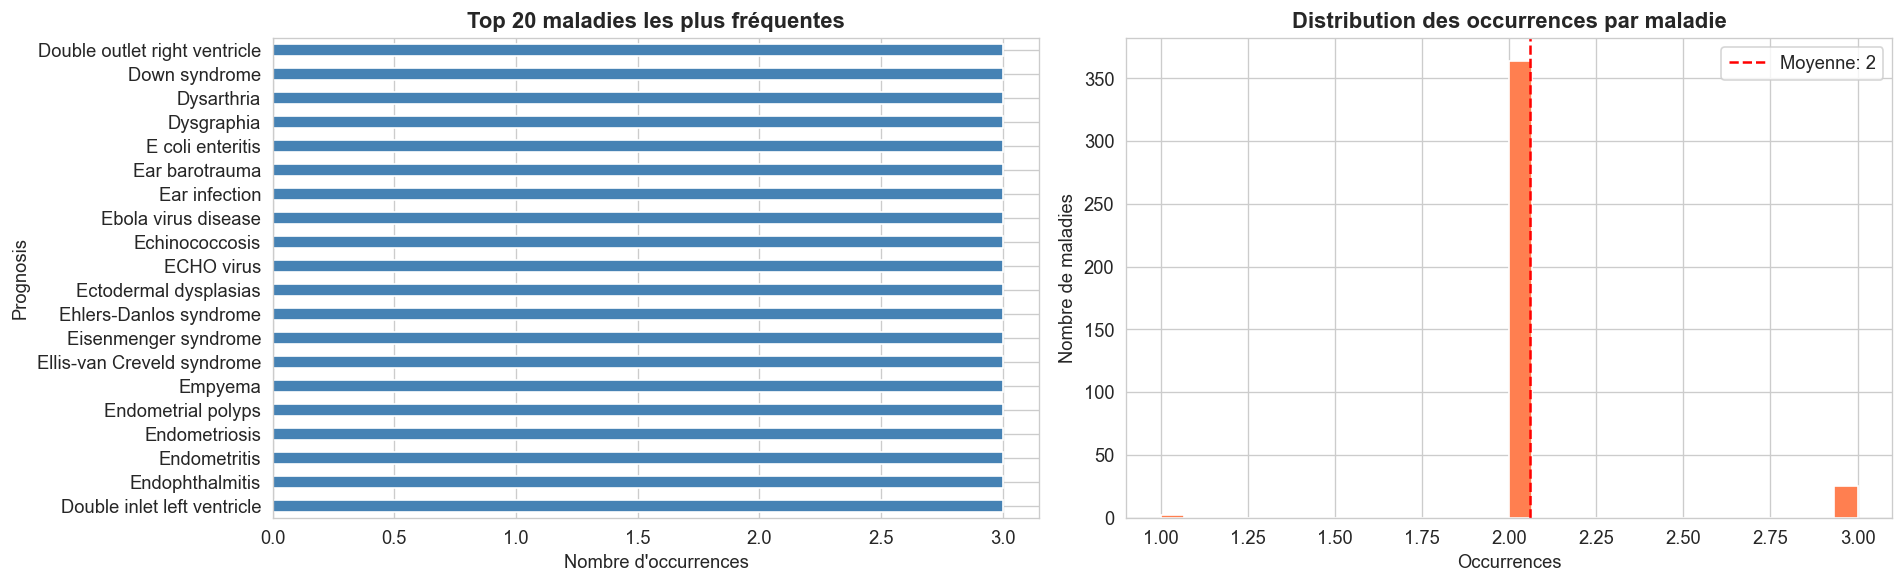

Maladies totales : 3
Occurrences min  : 1
Occurrences max  : 3
Occurrences moy  : 2.1


In [6]:
# 2.1 Distribution des maladies
disease_counts = df['Prognosis'].value_counts()

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Top 20 maladies
disease_counts.head(20).plot(kind='barh', ax=axes[0], color='steelblue')
axes[0].set_title('Top 20 maladies les plus fréquentes', fontweight='bold')
axes[0].set_xlabel('Nombre d\'occurrences')
axes[0].invert_yaxis()

# Distribution générale
axes[1].hist(disease_counts.values, bins=30, color='coral', edgecolor='white')
axes[1].set_title('Distribution des occurrences par maladie', fontweight='bold')
axes[1].set_xlabel('Occurrences')
axes[1].set_ylabel('Nombre de maladies')
axes[1].axvline(disease_counts.mean(), color='red', linestyle='--', label=f'Moyenne: {disease_counts.mean():.0f}')
axes[1].legend()

plt.tight_layout()
plt.show()

print(f'Maladies totales : {disease_counts.nunique()}')
print(f'Occurrences min  : {disease_counts.min()}')
print(f'Occurrences max  : {disease_counts.max()}')
print(f'Occurrences moy  : {disease_counts.mean():.1f}')

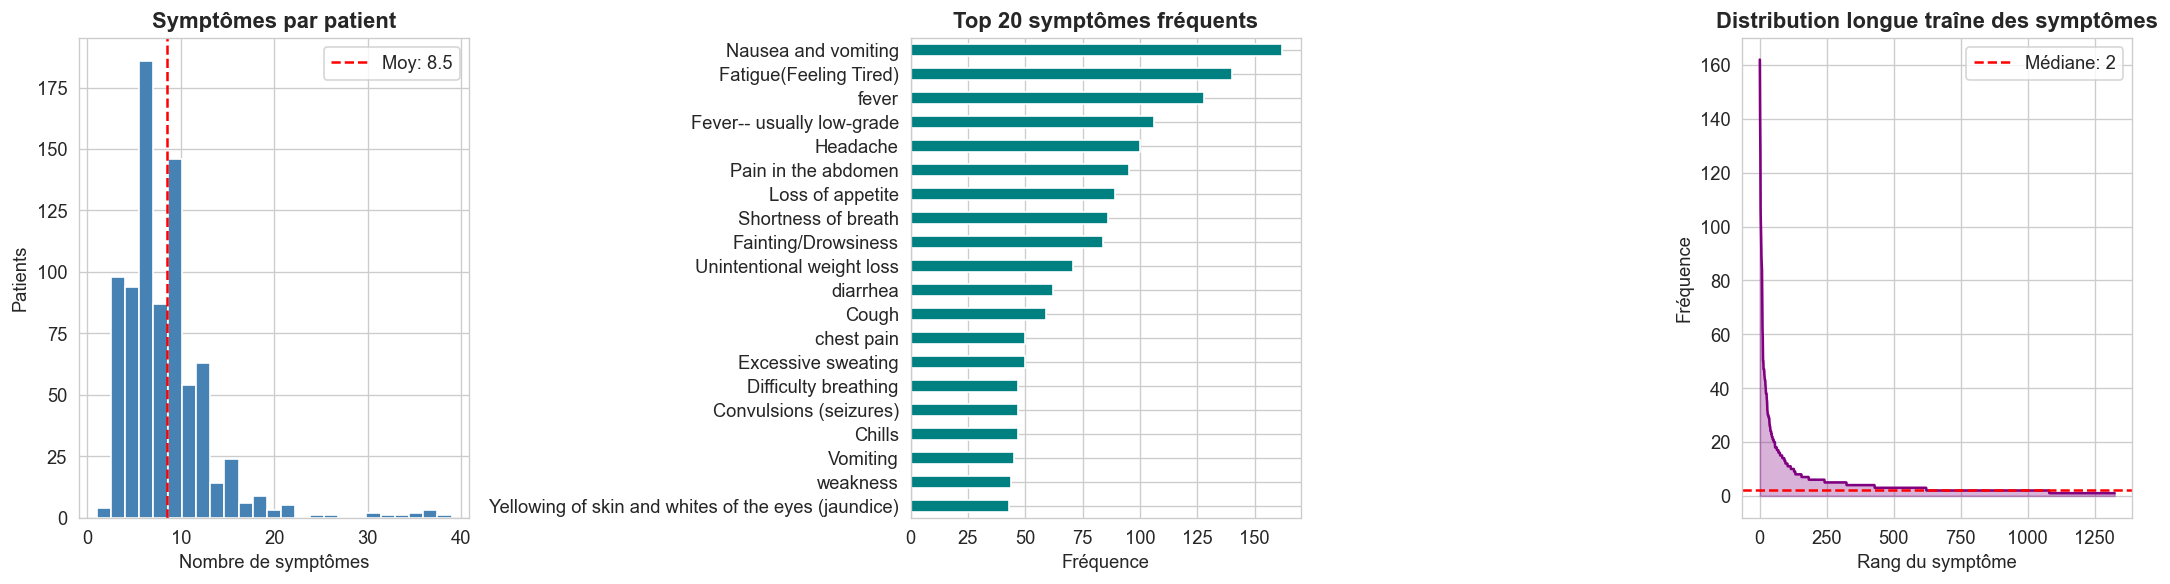

Total symptômes    : 1326
Symptômes jamais vus (freq=0) : 0
Symptômes rares (freq<5)      : 1002
Symptômes communs (freq>100)  : 4


In [7]:
# 2.2 Analyse des symptômes
df['symptom_count'] = df[symptom_cols].sum(axis=1)
symptom_freq = df[symptom_cols].sum().sort_values(ascending=False)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Distribution du nombre de symptômes par patient
axes[0].hist(df['symptom_count'], bins=25, color='steelblue', edgecolor='white')
axes[0].set_title('Symptômes par patient', fontweight='bold')
axes[0].set_xlabel('Nombre de symptômes')
axes[0].set_ylabel('Patients')
axes[0].axvline(df['symptom_count'].mean(), color='red', linestyle='--',
                label=f'Moy: {df["symptom_count"].mean():.1f}')
axes[0].legend()

# Top 20 symptômes
symptom_freq.head(20).plot(kind='barh', ax=axes[1], color='teal')
axes[1].set_title('Top 20 symptômes fréquents', fontweight='bold')
axes[1].set_xlabel('Fréquence')
axes[1].invert_yaxis()

# Symptômes rares (longue traîne)
axes[2].plot(range(len(symptom_freq)), symptom_freq.values, color='purple')
axes[2].fill_between(range(len(symptom_freq)), symptom_freq.values, alpha=0.3, color='purple')
axes[2].set_title('Distribution longue traîne des symptômes', fontweight='bold')
axes[2].set_xlabel('Rang du symptôme')
axes[2].set_ylabel('Fréquence')
axes[2].axhline(y=symptom_freq.median(), color='red', linestyle='--',
                label=f'Médiane: {symptom_freq.median():.0f}')
axes[2].legend()

plt.tight_layout()
plt.show()

print(f'Total symptômes    : {len(symptom_cols)}')
print(f'Symptômes jamais vus (freq=0) : {(symptom_freq == 0).sum()}')
print(f'Symptômes rares (freq<5)      : {(symptom_freq < 5).sum()}')
print(f'Symptômes communs (freq>100)  : {(symptom_freq > 100).sum()}')

=== Distribution des poids de gravité (Symptom-severity.csv) ===
           weight
count  133.000000
mean     4.225564
std      1.323543
min      1.000000
25%      3.000000
50%      4.000000
75%      5.000000
max      7.000000


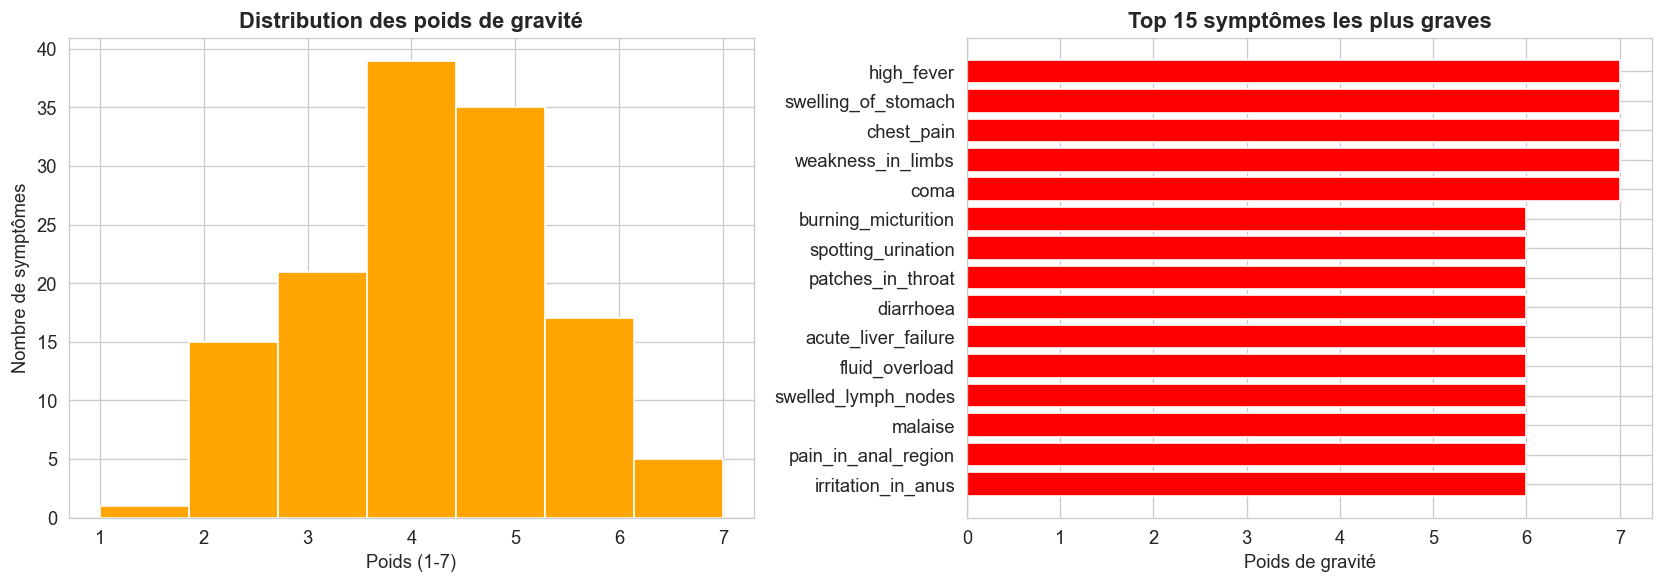

In [8]:
# 2.3 Analyse des poids de gravité des symptômes
print('=== Distribution des poids de gravité (Symptom-severity.csv) ===')
print(severity_df.describe())

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Distribution des poids
axes[0].hist(severity_df['weight'], bins=7, color='orange', edgecolor='white')
axes[0].set_title('Distribution des poids de gravité', fontweight='bold')
axes[0].set_xlabel('Poids (1-7)')
axes[0].set_ylabel('Nombre de symptômes')

# Top 15 symptômes les plus graves
top_severe = severity_df.nlargest(15, 'weight')
axes[1].barh(top_severe['Symptom'], top_severe['weight'], color='red')
axes[1].set_title('Top 15 symptômes les plus graves', fontweight='bold')
axes[1].set_xlabel('Poids de gravité')
axes[1].invert_yaxis()

plt.tight_layout()
plt.show()

## 3. Qualité des données

In [9]:
print('=== Rapport de qualité des données ===')
print(f'\n📊 Dimensions          : {df.shape}')
print(f'   Valeurs nulles      : {df.isnull().sum().sum()} ✅')
print(f'   Doublons exacts     : {df.duplicated().sum()}')
print(f'   Maladies uniques    : {df["Prognosis"].nunique()}')
print(f'   Symptômes actifs    : {len(symptom_cols)}')

# Vérifier que les features sont bien binaires
unique_vals = set()
for col in symptom_cols:
    unique_vals.update(df[col].unique())
print(f'\n   Valeurs uniques dans les features : {sorted(unique_vals)}')
print(f'   ✅ Features 100% binaires (0/1)') if unique_vals == {0, 1} or unique_vals == {0.0, 1.0} else print('⚠️  Attention : valeurs non binaires détectées')

# Densité de la matrice
total_cells = df[symptom_cols].size
non_zero    = df[symptom_cols].sum().sum()
density     = non_zero / total_cells * 100
print(f'\n   Densité de la matrice symptômes : {density:.2f}%')
print(f'   (matrice très creuse — favorable pour Random Forest)')

# Déséquilibre par maladie
disease_counts = df['Prognosis'].value_counts()
print(f'\n=== Équilibre des classes (maladies) ===')
print(f'   Ratio max/min : {disease_counts.max() / disease_counts.min():.1f}x')
print(f'   ➜ class_weight="balanced" sera appliqué pour compenser')

=== Rapport de qualité des données ===

📊 Dimensions          : (805, 1328)
   Valeurs nulles      : 0 ✅
   Doublons exacts     : 179
   Maladies uniques    : 391
   Symptômes actifs    : 1326

   Valeurs uniques dans les features : [np.int64(0), np.int64(1)]
   ✅ Features 100% binaires (0/1)

   Densité de la matrice symptômes : 0.64%
   (matrice très creuse — favorable pour Random Forest)

=== Équilibre des classes (maladies) ===
   Ratio max/min : 3.0x
   ➜ class_weight="balanced" sera appliqué pour compenser


## 4. Mapping orientation via Groq LLM

In [10]:
from groq import Groq

MAPPING_FILE = f'{PROCESSED_PATH}disease_orientation.json'
DISEASES     = df['Prognosis'].unique().tolist()
print(f'Maladies à classifier : {len(DISEASES)}')

def generate_mapping_with_llm(diseases: list) -> dict:
    client     = Groq(api_key=GROQ_API_KEY)
    mapping    = {}
    batch_size = 50
    batches    = [diseases[i:i+batch_size] for i in range(0, len(diseases), batch_size)]

    for i, batch in enumerate(batches):
        print(f'  Batch {i+1}/{len(batches)}...')
        diseases_str = '\n'.join([f'- {d}' for d in batch])
        prompt = f"""You are a medical triage expert. Classify each disease into exactly one category.

RULES:
- "urgences": life-threatening (heart attack, stroke, sepsis, meningitis...)
- "surveillance": mild, manageable at home (common cold, minor rash...)
- "medecin": everything else requiring a doctor

Target: ~25% urgences, ~40% medecin, ~35% surveillance

Diseases:
{diseases_str}

Return ONLY valid JSON like: {{"Disease": "orientation", ...}}"""

        response = client.chat.completions.create(
            model='llama-3.3-70b-versatile',
            messages=[{'role': 'user', 'content': prompt}],
            temperature=0.1,
            max_tokens=2000
        )
        raw = response.choices[0].message.content.strip()
        if '```json' in raw:
            raw = raw.split('```json')[1].split('```')[0].strip()
        elif '```' in raw:
            raw = raw.split('```')[1].split('```')[0].strip()
        mapping.update(json.loads(raw))

    return mapping

if os.path.exists(MAPPING_FILE):
    print('✅ Mapping existant chargé depuis le disque')
    with open(MAPPING_FILE) as f:
        DISEASE_ORIENTATION = json.load(f)
else:
    print('🤖 Appel Groq LLM...')
    DISEASE_ORIENTATION = generate_mapping_with_llm(DISEASES)
    with open(MAPPING_FILE, 'w') as f:
        json.dump(DISEASE_ORIENTATION, f, indent=2, ensure_ascii=False)

# Inverser si nécessaire {orientation: [maladies]} → {maladie: orientation}
if isinstance(list(DISEASE_ORIENTATION.values())[0], list):
    flat = {}
    for orient, diseases in DISEASE_ORIENTATION.items():
        for d in diseases:
            flat[d.strip()] = orient
    DISEASE_ORIENTATION = flat

counts = Counter(DISEASE_ORIENTATION.values())
print(f'\n📊 Mapping final ({len(DISEASE_ORIENTATION)} maladies) :')
for k, v in counts.items():
    pct = v / len(DISEASE_ORIENTATION) * 100
    print(f'   {k:15} : {v:4d} maladies ({pct:.1f}%)')

Maladies à classifier : 391
✅ Mapping existant chargé depuis le disque

📊 Mapping final (391 maladies) :
   surveillance    :   76 maladies (19.4%)
   urgences        :  111 maladies (28.4%)
   medecin         :  204 maladies (52.2%)


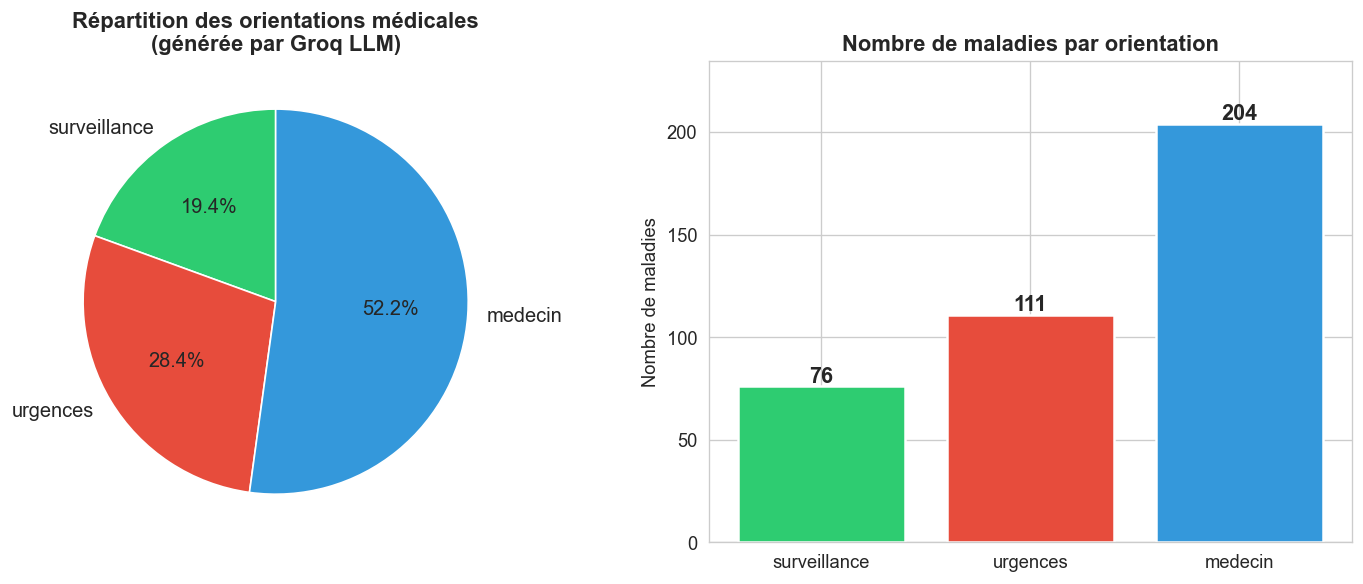

In [11]:
# Visualisation du mapping
counts_series = pd.Series(Counter(DISEASE_ORIENTATION.values()))

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Pie chart
colors_list = [COLORS.get(k, 'gray') for k in counts_series.index]
axes[0].pie(counts_series.values, labels=counts_series.index,
            autopct='%1.1f%%', colors=colors_list,
            startangle=90, textprops={'fontsize': 12})
axes[0].set_title('Répartition des orientations médicales\n(générée par Groq LLM)', fontweight='bold')

# Bar chart
bars = axes[1].bar(counts_series.index, counts_series.values,
                   color=colors_list, edgecolor='white', linewidth=1.5)
for bar, val in zip(bars, counts_series.values):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 2,
                 str(val), ha='center', fontweight='bold', fontsize=13)
axes[1].set_title('Nombre de maladies par orientation', fontweight='bold')
axes[1].set_ylabel('Nombre de maladies')
axes[1].set_ylim(0, counts_series.max() * 1.15)

plt.tight_layout()
plt.show()

## 5. Feature Engineering & Préparation

In [12]:
# Score de gravité
ORIENTATION_BASE = {'urgences': 85, 'medecin': 65, 'surveillance': 30}

severity_dict = dict(zip(
    severity_df['Symptom'].str.strip().str.lower().str.replace('_', ' '),
    severity_df['weight']
))

def calculate_score(row, orientation):
    active = [col for col in symptom_cols if row[col] == 1]
    if not active:
        return float(ORIENTATION_BASE.get(orientation, 30))
    weights = [severity_dict.get(s.lower(), 3) for s in active]
    base    = ORIENTATION_BASE.get(orientation, 65)
    score   = (base * 0.6) + ((np.mean(weights) / 7 * 100) * 0.4)
    return round(float(np.clip(score + np.random.uniform(-3, 3), 0, 100)), 1)

def get_risk_level(score):
    if score >= 80:   return 'critical'
    elif score >= 60: return 'high'
    elif score >= 40: return 'medium'
    else:             return 'low'

df['orientation']    = df['Prognosis'].map(lambda x: DISEASE_ORIENTATION.get(x, 'medecin'))
df['severity_score'] = df.apply(lambda r: calculate_score(r, r['orientation']), axis=1)
df['risk_level']     = df['severity_score'].apply(get_risk_level)

df.to_csv(f'{PROCESSED_PATH}dataset_final.csv', index=False)

print('📊 Distribution des orientations :')
print(df['orientation'].value_counts())
print('\n📊 Score moyen par orientation :')
print(df.groupby('orientation')['severity_score'].agg(['mean', 'std', 'min', 'max']).round(2))

📊 Distribution des orientations :
orientation
medecin         419
urgences        227
surveillance    159
Name: count, dtype: int64

📊 Score moyen par orientation :
               mean   std   min   max
orientation                          
medecin       56.74  2.09  51.8  64.6
surveillance  35.35  1.90  31.5  41.1
urgences      68.55  2.14  64.7  77.4


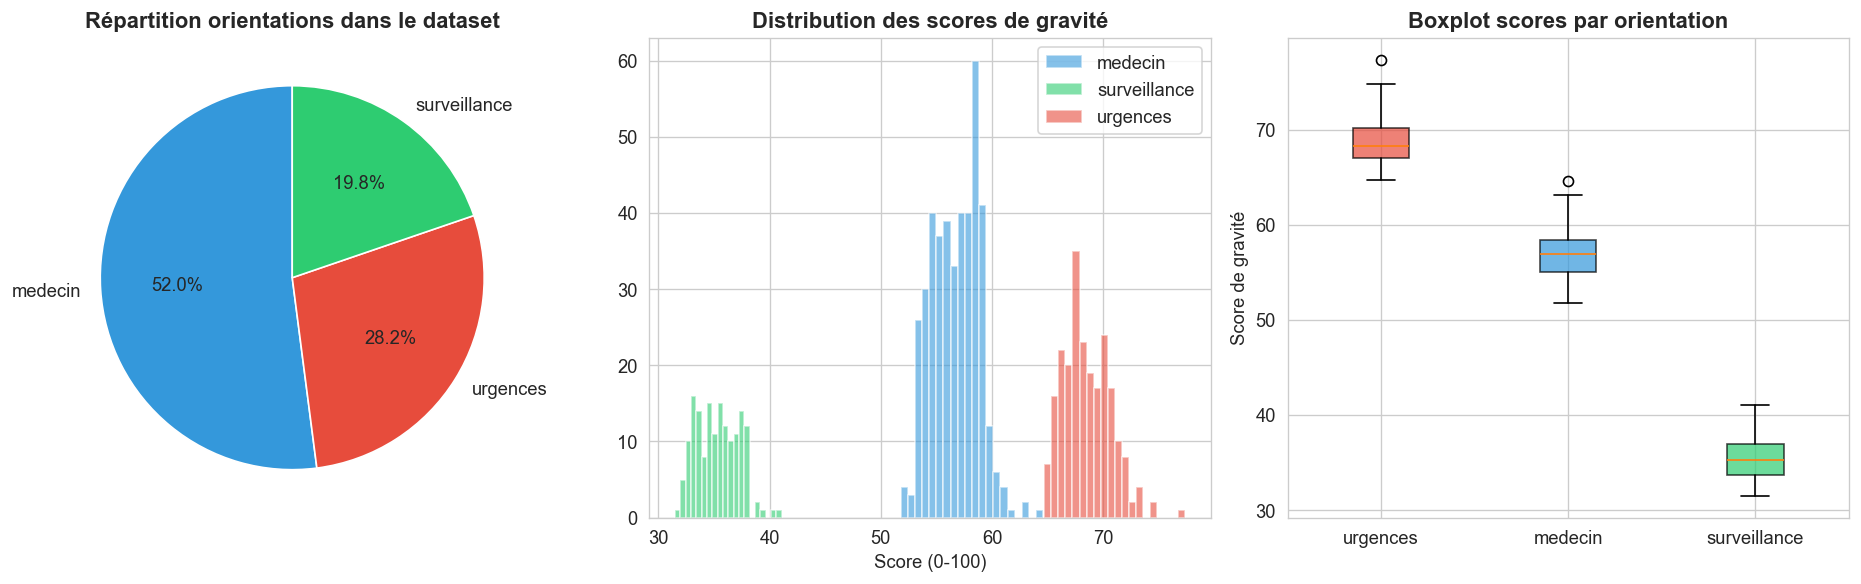

In [13]:
# Visualisation des scores de gravité
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Pie orientation
orient_counts = df['orientation'].value_counts()
colors_list   = [COLORS[o] for o in orient_counts.index]
axes[0].pie(orient_counts.values, labels=orient_counts.index,
            autopct='%1.1f%%', colors=colors_list, startangle=90)
axes[0].set_title('Répartition orientations dans le dataset', fontweight='bold')

# Distribution scores par orientation
for orient, grp in df.groupby('orientation'):
    axes[1].hist(grp['severity_score'], bins=20, alpha=0.6,
                 label=orient, color=COLORS[orient])
axes[1].set_title('Distribution des scores de gravité', fontweight='bold')
axes[1].set_xlabel('Score (0-100)')
axes[1].legend()

# Boxplot
data_by_orient = [df[df['orientation'] == o]['severity_score'].values
                  for o in ['urgences', 'medecin', 'surveillance']]
bp = axes[2].boxplot(data_by_orient, labels=['urgences', 'medecin', 'surveillance'],
                     patch_artist=True)
for patch, color in zip(bp['boxes'], [COLORS['urgences'], COLORS['medecin'], COLORS['surveillance']]):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)
axes[2].set_title('Boxplot scores par orientation', fontweight='bold')
axes[2].set_ylabel('Score de gravité')

plt.tight_layout()
plt.show()

## 6. Analyse de la matrice de features

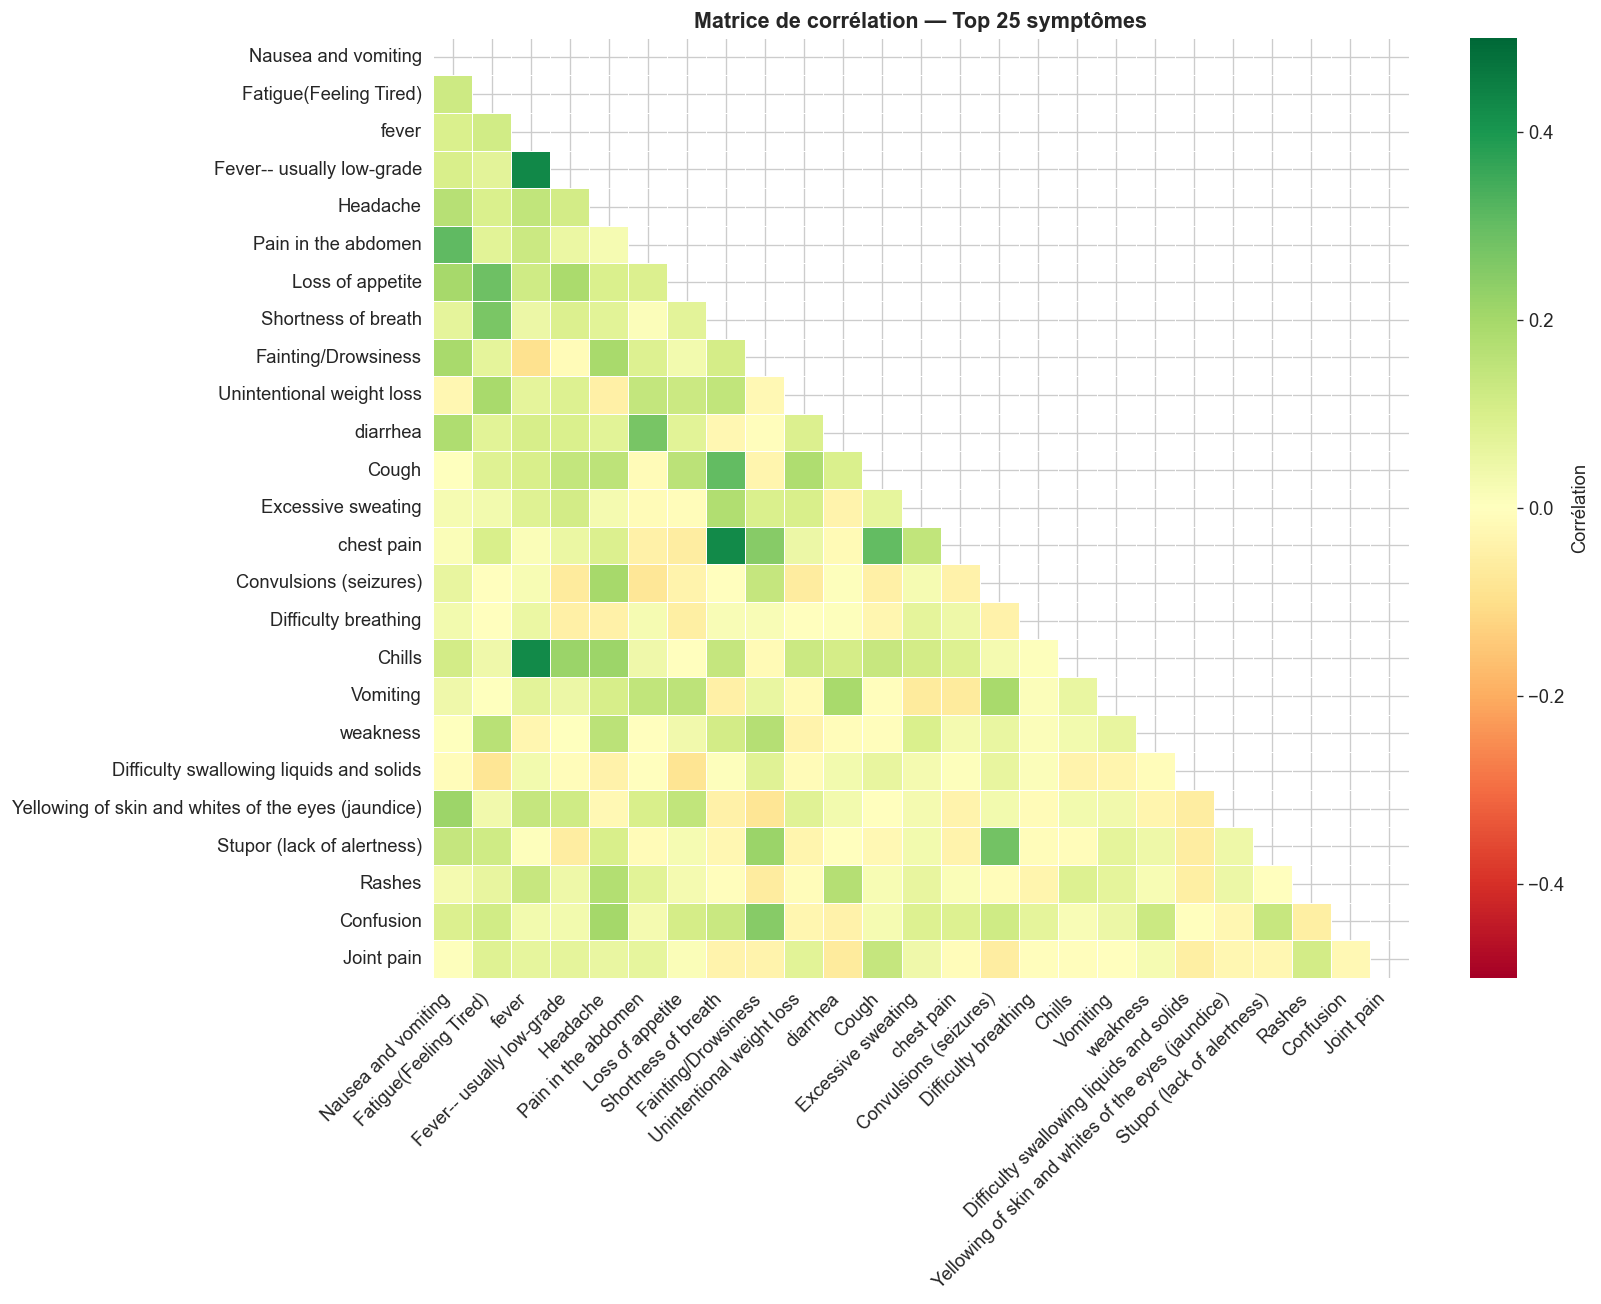

Paires corrélées (|r| > 0.3) : 6
   fever                          ↔ Fever-- usually low-grade      : r=0.433
   fever                          ↔ Chills                         : r=0.428
   Shortness of breath            ↔ chest pain                     : r=0.428
   Nausea and vomiting            ↔ Pain in the abdomen            : r=0.306
   Shortness of breath            ↔ Cough                          : r=0.304
   Cough                          ↔ chest pain                     : r=0.303


In [14]:
# 6.1 Corrélation symptômes les plus fréquents
top_symptoms = df[symptom_cols].sum().nlargest(25).index.tolist()
corr_matrix  = df[top_symptoms].corr()

plt.figure(figsize=(14, 11))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, cmap='RdYlGn', center=0,
            annot=False, linewidths=0.3, vmin=-0.5, vmax=0.5,
            cbar_kws={'label': 'Corrélation'})
plt.title('Matrice de corrélation — Top 25 symptômes', fontweight='bold', fontsize=13)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

# Paires fortement corrélées
corr_pairs = []
for i in range(len(corr_matrix.columns)):
    for j in range(i+1, len(corr_matrix.columns)):
        val = corr_matrix.iloc[i, j]
        if abs(val) > 0.3:
            corr_pairs.append((corr_matrix.columns[i], corr_matrix.columns[j], round(val, 3)))

corr_pairs.sort(key=lambda x: abs(x[2]), reverse=True)
print(f'Paires corrélées (|r| > 0.3) : {len(corr_pairs)}')
for a, b, r in corr_pairs[:10]:
    print(f'   {a:30} ↔ {b:30} : r={r}')

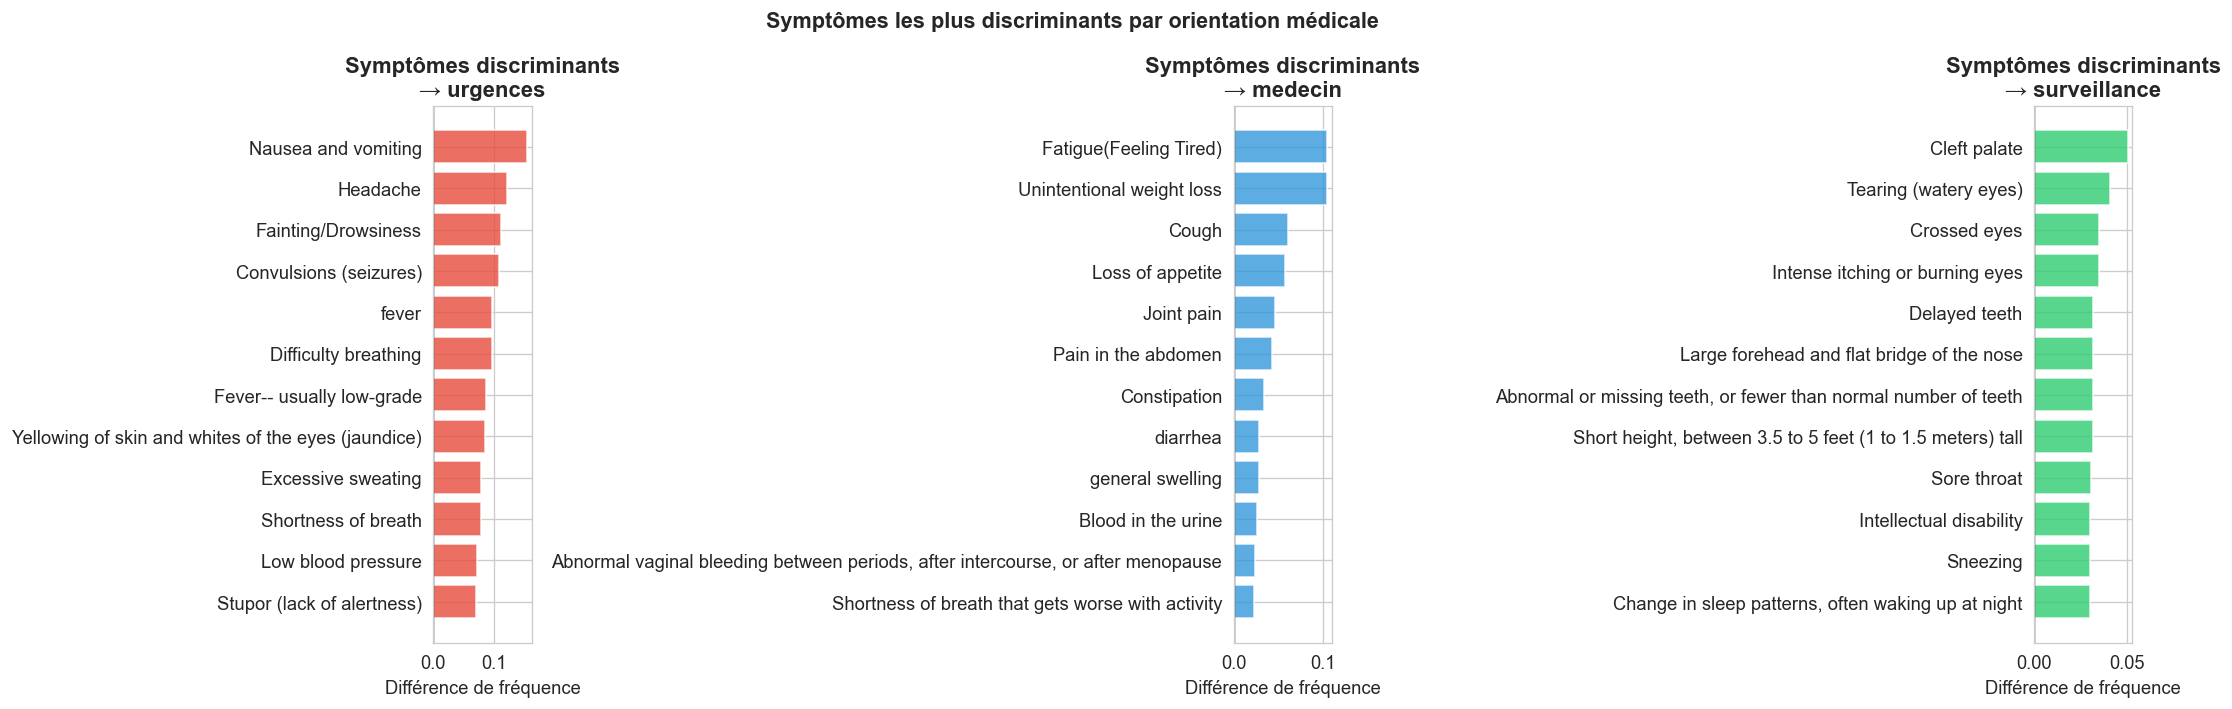

In [15]:
# 6.2 Symptômes discriminants par orientation
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

for ax, orient in zip(axes, ['urgences', 'medecin', 'surveillance']):
    mask_orient = df['orientation'] == orient
    mask_other  = df['orientation'] != orient

    freq_orient = df[mask_orient][symptom_cols].mean()
    freq_other  = df[mask_other][symptom_cols].mean()
    diff        = (freq_orient - freq_other).nlargest(12)

    ax.barh(diff.index, diff.values, color=COLORS[orient], alpha=0.8)
    ax.set_title(f'Symptômes discriminants\n→ {orient}', fontweight='bold')
    ax.set_xlabel('Différence de fréquence')
    ax.invert_yaxis()
    ax.axvline(0, color='black', linewidth=0.8)

plt.suptitle('Symptômes les plus discriminants par orientation médicale', fontweight='bold', fontsize=13)
plt.tight_layout()
plt.show()

## 7. Entraînement Random Forest

In [16]:
# Préparation X, y
X  = df[symptom_cols].values
le = LabelEncoder()
y  = le.fit_transform(df['orientation'])
joblib.dump(le, f'{MODELS_PATH}label_encoder.joblib')

with open(f'{PROCESSED_PATH}symptom_cols.json', 'w') as f:
    json.dump(symptom_cols, f)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f'✅ Features shape  : {X.shape}')
print(f'   Classes         : {le.classes_}')
print(f'   Train           : {X_train.shape[0]} échantillons')
print(f'   Test            : {X_test.shape[0]} échantillons')
print(f'   Ratio train/test: {X_train.shape[0]/X_test.shape[0]:.1f}x')

✅ Features shape  : (805, 1326)
   Classes         : ['medecin' 'surveillance' 'urgences']
   Train           : 644 échantillons
   Test            : 161 échantillons
   Ratio train/test: 4.0x


In [17]:
# Justification du choix Random Forest
print('=== Pourquoi Random Forest pour MediAssist ? ===')
print()
print('✅ 1. Matrice sparse (1326 features binaires)')
print('      Random Forest gère naturellement les features binaires')
print('      sans normalisation préalable')
print()
print('✅ 2. Robustesse au déséquilibre')
print('      class_weight="balanced" compense automatiquement')
print('      les classes sous-représentées')
print()
print('✅ 3. Interprétabilité médicale')
print('      feature_importances_ donne les symptômes les plus')
print('      déterminants → explicable au médecin')
print()
print('✅ 4. Pas de surapprentissage sur données binaires')
print('      Bagging + profondeur contrôlée = bonne généralisation')
print()
print('✅ 5. Probabilités de confiance')
print('      predict_proba() fournit un score de certitude')
print('      essentiel dans un contexte médical')

=== Pourquoi Random Forest pour MediAssist ? ===

✅ 1. Matrice sparse (1326 features binaires)
      Random Forest gère naturellement les features binaires
      sans normalisation préalable

✅ 2. Robustesse au déséquilibre
      class_weight="balanced" compense automatiquement
      les classes sous-représentées

✅ 3. Interprétabilité médicale
      feature_importances_ donne les symptômes les plus
      déterminants → explicable au médecin

✅ 4. Pas de surapprentissage sur données binaires
      Bagging + profondeur contrôlée = bonne généralisation

✅ 5. Probabilités de confiance
      predict_proba() fournit un score de certitude
      essentiel dans un contexte médical


In [18]:
# Entraînement Random Forest
print('🔄 Entraînement Random Forest...')

rf = RandomForestClassifier(
    n_estimators   = 200,
    max_depth      = 20,
    min_samples_split = 2,
    min_samples_leaf  = 1,
    max_features   = 'sqrt',
    class_weight   = 'balanced',
    random_state   = 42,
    n_jobs         = -1
)

rf.fit(X_train, y_train)
y_pred = rf.predict(X_test)
y_proba = rf.predict_proba(X_test)

accuracy = accuracy_score(y_test, y_pred)
print(f'\n✅ Entraînement terminé')
print(f'   Accuracy test : {accuracy:.4f} ({accuracy*100:.2f}%)')

🔄 Entraînement Random Forest...

✅ Entraînement terminé
   Accuracy test : 0.6398 (63.98%)


## 8. Validation croisée & Courbe d'apprentissage

=== Validation croisée 5-Fold ===
   Fold 1 : 0.6770
   Fold 2 : 0.6832
   Fold 3 : 0.6522
   Fold 4 : 0.6149
   Fold 5 : 0.6522
   ─────────────────
   Moyenne : 0.6559 ± 0.0241
   Min     : 0.6149
   Max     : 0.6832


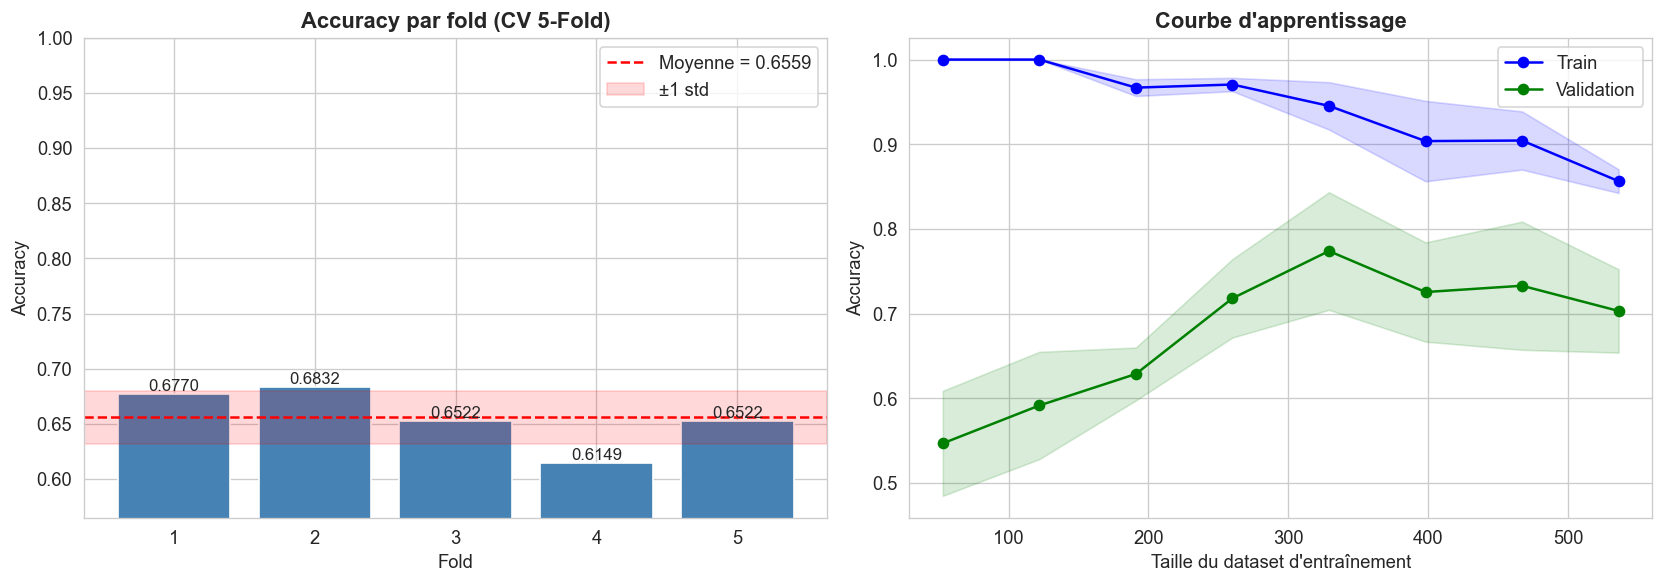

In [19]:
# Validation croisée stratifiée
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = cross_val_score(rf, X, y, cv=skf, scoring='accuracy', n_jobs=-1)

print('=== Validation croisée 5-Fold ===')
for i, score in enumerate(cv_scores, 1):
    print(f'   Fold {i} : {score:.4f}')
print(f'   ─────────────────')
print(f'   Moyenne : {cv_scores.mean():.4f} ± {cv_scores.std():.4f}')
print(f'   Min     : {cv_scores.min():.4f}')
print(f'   Max     : {cv_scores.max():.4f}')

# Visualisation
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# CV scores par fold
bars = axes[0].bar(range(1, 6), cv_scores, color='steelblue', edgecolor='white')
axes[0].axhline(cv_scores.mean(), color='red', linestyle='--',
                label=f'Moyenne = {cv_scores.mean():.4f}')
axes[0].axhspan(cv_scores.mean() - cv_scores.std(),
                cv_scores.mean() + cv_scores.std(),
                alpha=0.15, color='red', label='±1 std')
for bar, val in zip(bars, cv_scores):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.003,
                 f'{val:.4f}', ha='center', fontsize=10)
axes[0].set_title('Accuracy par fold (CV 5-Fold)', fontweight='bold')
axes[0].set_xlabel('Fold')
axes[0].set_ylabel('Accuracy')
axes[0].set_ylim(cv_scores.min() - 0.05, 1.0)
axes[0].legend()

# Courbe d'apprentissage
train_sizes, train_scores, val_scores = learning_curve(
    rf, X, y, cv=3, scoring='accuracy',
    train_sizes=np.linspace(0.1, 1.0, 8), n_jobs=-1
)
axes[1].plot(train_sizes, train_scores.mean(axis=1), 'o-', color='blue', label='Train')
axes[1].fill_between(train_sizes,
                     train_scores.mean(axis=1) - train_scores.std(axis=1),
                     train_scores.mean(axis=1) + train_scores.std(axis=1),
                     alpha=0.15, color='blue')
axes[1].plot(train_sizes, val_scores.mean(axis=1), 'o-', color='green', label='Validation')
axes[1].fill_between(train_sizes,
                     val_scores.mean(axis=1) - val_scores.std(axis=1),
                     val_scores.mean(axis=1) + val_scores.std(axis=1),
                     alpha=0.15, color='green')
axes[1].set_title('Courbe d\'apprentissage', fontweight='bold')
axes[1].set_xlabel('Taille du dataset d\'entraînement')
axes[1].set_ylabel('Accuracy')
axes[1].legend()

plt.tight_layout()
plt.show()

## 9. Évaluation approfondie

In [20]:
# Rapport de classification complet
print('=== Rapport de classification ===')
print(classification_report(y_test, y_pred, target_names=le.classes_))

# Métriques par classe
precision, recall, f1, support = precision_recall_fscore_support(
    y_test, y_pred, labels=range(len(le.classes_))
)

metrics_df = pd.DataFrame({
    'Classe'   : le.classes_,
    'Precision': precision.round(4),
    'Recall'   : recall.round(4),
    'F1-Score' : f1.round(4),
    'Support'  : support
})
print('\n=== Métriques détaillées ===')
print(metrics_df.to_string(index=False))

=== Rapport de classification ===
              precision    recall  f1-score   support

     medecin       0.72      0.60      0.65        84
surveillance       0.47      0.84      0.61        32
    urgences       0.74      0.58      0.65        45

    accuracy                           0.64       161
   macro avg       0.65      0.67      0.64       161
weighted avg       0.68      0.64      0.64       161


=== Métriques détaillées ===
      Classe  Precision  Recall  F1-Score  Support
     medecin     0.7246  0.5952    0.6536       84
surveillance     0.4737  0.8438    0.6067       32
    urgences     0.7429  0.5778    0.6500       45


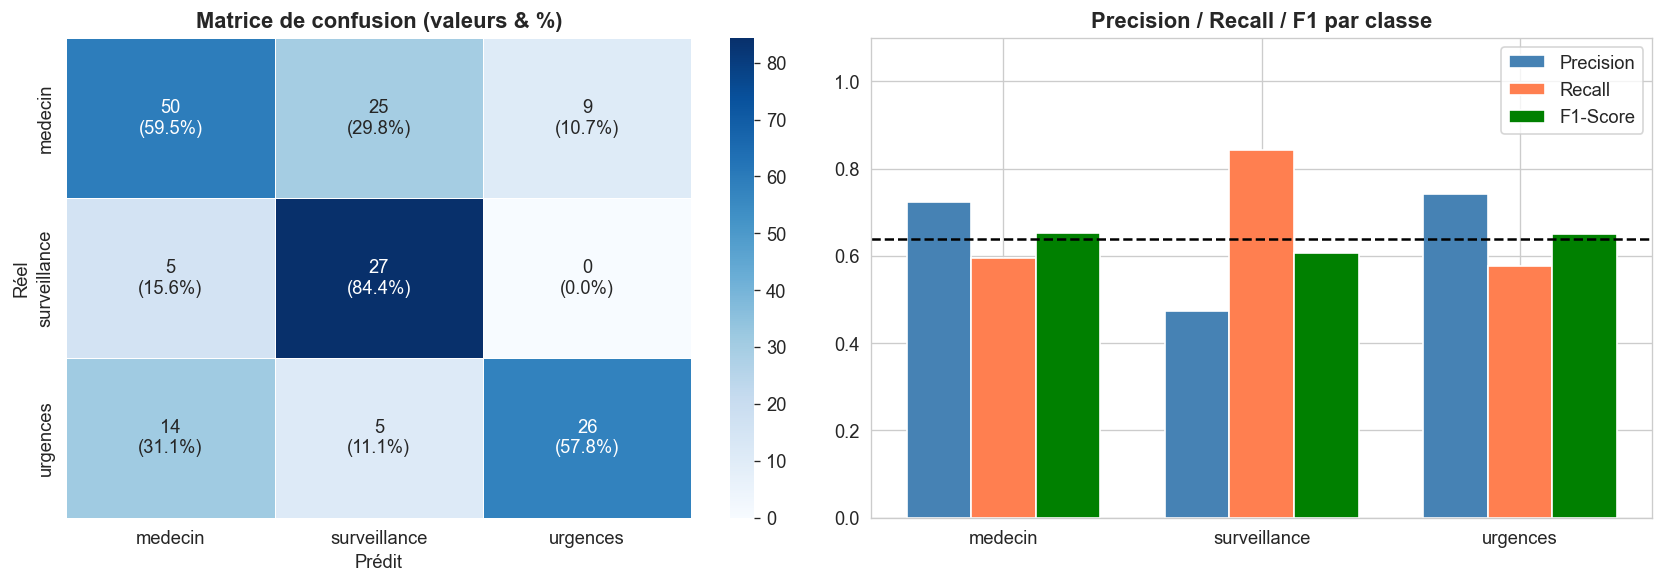

In [21]:
# Matrice de confusion + métriques visuelles
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Matrice de confusion
cm = confusion_matrix(y_test, y_pred)
cm_pct = cm.astype(float) / cm.sum(axis=1)[:, np.newaxis] * 100

labels_annot = np.array([[f'{cm[i,j]}\n({cm_pct[i,j]:.1f}%)'
                           for j in range(cm.shape[1])]
                          for i in range(cm.shape[0])])

sns.heatmap(cm_pct, annot=labels_annot, fmt='', cmap='Blues',
            xticklabels=le.classes_, yticklabels=le.classes_,
            ax=axes[0], linewidths=0.5)
axes[0].set_title('Matrice de confusion (valeurs & %)', fontweight='bold')
axes[0].set_ylabel('Réel')
axes[0].set_xlabel('Prédit')

# Métriques par classe
x = np.arange(len(le.classes_))
w = 0.25
axes[1].bar(x - w,   precision, w, label='Precision', color='steelblue')
axes[1].bar(x,       recall,    w, label='Recall',    color='coral')
axes[1].bar(x + w,   f1,        w, label='F1-Score',  color='green')
axes[1].set_xticks(x)
axes[1].set_xticklabels(le.classes_)
axes[1].set_ylim(0, 1.1)
axes[1].set_title('Precision / Recall / F1 par classe', fontweight='bold')
axes[1].legend()
axes[1].axhline(y=accuracy, color='black', linestyle='--',
                label=f'Accuracy globale: {accuracy:.4f}')

plt.tight_layout()
plt.show()

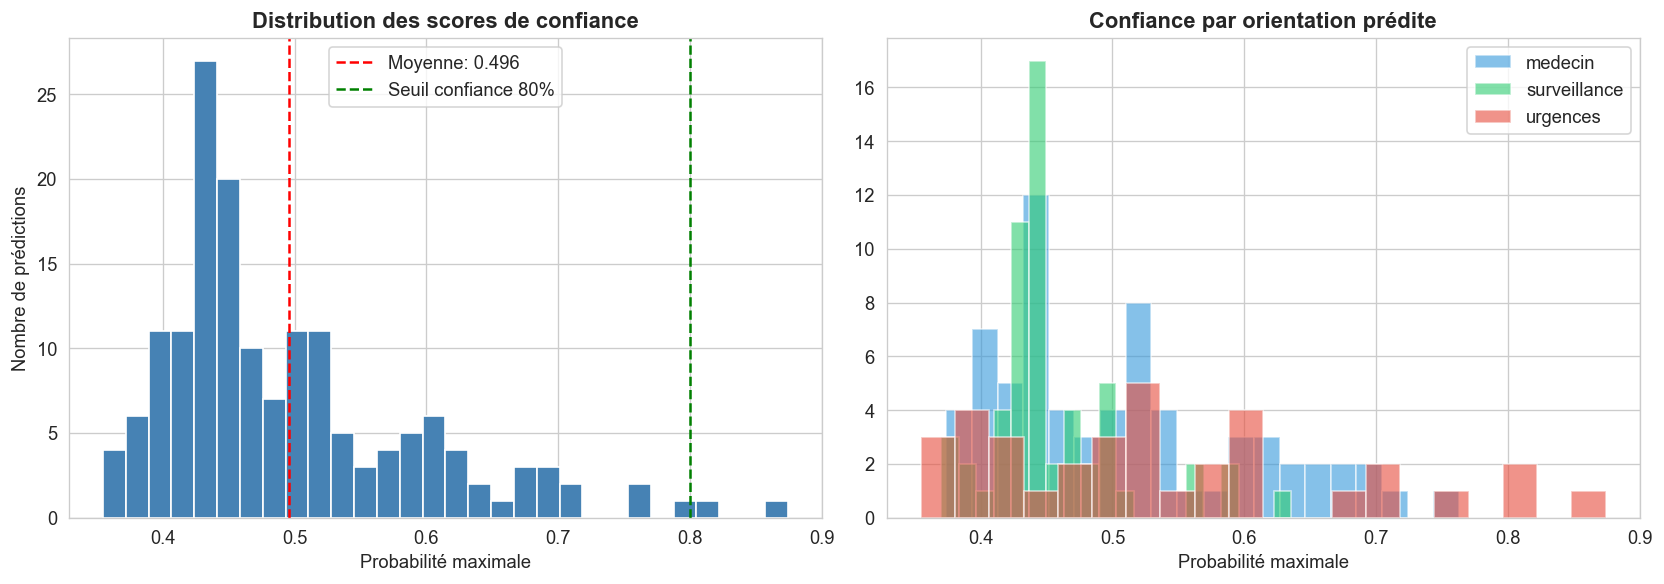

Prédictions à haute confiance (≥80%) : 3/161 (1.9%)


In [22]:
# Distribution des probabilités de confiance
max_probas = y_proba.max(axis=1)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Distribution globale
axes[0].hist(max_probas, bins=30, color='steelblue', edgecolor='white')
axes[0].axvline(max_probas.mean(), color='red', linestyle='--',
                label=f'Moyenne: {max_probas.mean():.3f}')
axes[0].axvline(0.8, color='green', linestyle='--', label='Seuil confiance 80%')
axes[0].set_title('Distribution des scores de confiance', fontweight='bold')
axes[0].set_xlabel('Probabilité maximale')
axes[0].set_ylabel('Nombre de prédictions')
axes[0].legend()

# Confiance par classe prédite
pred_classes = le.inverse_transform(y_pred)
for orient in le.classes_:
    mask = pred_classes == orient
    if mask.sum() > 0:
        axes[1].hist(max_probas[mask], bins=20, alpha=0.6,
                     label=orient, color=COLORS[orient])
axes[1].set_title('Confiance par orientation prédite', fontweight='bold')
axes[1].set_xlabel('Probabilité maximale')
axes[1].legend()

plt.tight_layout()
plt.show()

high_conf = (max_probas >= 0.8).sum()
print(f'Prédictions à haute confiance (≥80%) : {high_conf}/{len(max_probas)} ({high_conf/len(max_probas)*100:.1f}%)')

## 10. Analyse des erreurs

In [23]:
# Identifier les erreurs
errors_mask    = y_pred != y_test
error_indices  = np.where(errors_mask)[0]

print(f'Erreurs totales : {errors_mask.sum()} / {len(y_test)} ({errors_mask.sum()/len(y_test)*100:.2f}%)')

# Analyse des erreurs par paire réel → prédit
error_pairs = Counter()
for i in error_indices:
    real  = le.inverse_transform([y_test[i]])[0]
    pred  = le.inverse_transform([y_pred[i]])[0]
    error_pairs[(real, pred)] += 1

print('\nErreurs par paire (Réel → Prédit) :')
for (real, pred), count in sorted(error_pairs.items(), key=lambda x: -x[1]):
    pct = count / errors_mask.sum() * 100
    risk = '🚨 CRITIQUE' if real == 'urgences' and pred == 'surveillance' else ''
    print(f'   {real:15} → {pred:15} : {count:4d} cas ({pct:.1f}%) {risk}')

# Confiance sur les erreurs
error_conf = max_probas[errors_mask]
correct_conf = max_probas[~errors_mask]
print(f'\nConfiance moyenne sur erreurs  : {error_conf.mean():.3f}')
print(f'Confiance moyenne sur corrects : {correct_conf.mean():.3f}')
print(f'➜ Le modèle est moins confiant sur ses erreurs ✅')

Erreurs totales : 58 / 161 (36.02%)

Erreurs par paire (Réel → Prédit) :
   medecin         → surveillance    :   25 cas (43.1%) 
   urgences        → medecin         :   14 cas (24.1%) 
   medecin         → urgences        :    9 cas (15.5%) 
   surveillance    → medecin         :    5 cas (8.6%) 
   urgences        → surveillance    :    5 cas (8.6%) 🚨 CRITIQUE

Confiance moyenne sur erreurs  : 0.432
Confiance moyenne sur corrects : 0.531
➜ Le modèle est moins confiant sur ses erreurs ✅


## 11. Feature Importance & Interprétabilité

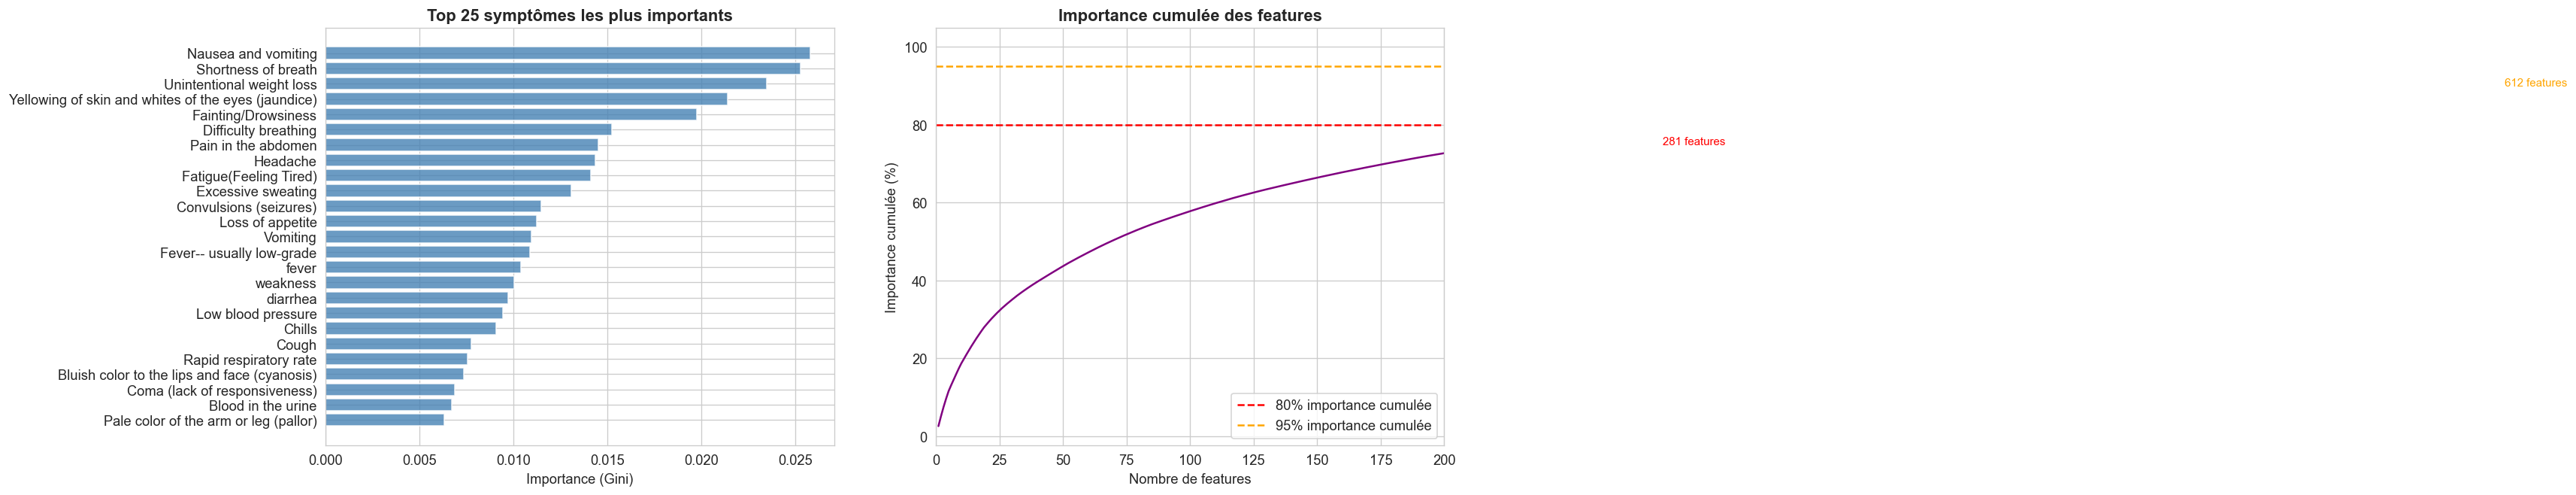


281 symptômes couvrent 80% de l'importance
612 symptômes couvrent 95% de l'importance
sur 1326 symptômes au total


In [24]:
# Feature importance globale
importances = rf.feature_importances_
top_idx     = np.argsort(importances)[::-1]

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Top 25 symptômes importants
n = 25
top_feats = [symptom_cols[i] for i in top_idx[:n]]
top_vals  = importances[top_idx[:n]]

bars = axes[0].barh(top_feats[::-1], top_vals[::-1], color='steelblue', alpha=0.8)
axes[0].set_title(f'Top {n} symptômes les plus importants', fontweight='bold')
axes[0].set_xlabel('Importance (Gini)')

# Courbe d'importance cumulée
cum_importance = np.cumsum(importances[top_idx])
axes[1].plot(range(1, len(cum_importance)+1), cum_importance * 100, color='purple')
axes[1].axhline(80, color='red', linestyle='--', label='80% importance cumulée')
axes[1].axhline(95, color='orange', linestyle='--', label='95% importance cumulée')

# Trouver combien de features pour 80% et 95%
n_80 = np.searchsorted(cum_importance, 0.80) + 1
n_95 = np.searchsorted(cum_importance, 0.95) + 1
axes[1].axvline(n_80, color='red', linestyle=':', alpha=0.5)
axes[1].axvline(n_95, color='orange', linestyle=':', alpha=0.5)
axes[1].text(n_80 + 5, 75, f'{n_80} features', color='red', fontsize=9)
axes[1].text(n_95 + 5, 90, f'{n_95} features', color='orange', fontsize=9)

axes[1].set_title('Importance cumulée des features', fontweight='bold')
axes[1].set_xlabel('Nombre de features')
axes[1].set_ylabel('Importance cumulée (%)')
axes[1].legend()
axes[1].set_xlim(0, 200)

plt.tight_layout()
plt.show()

print(f'\n{n_80} symptômes couvrent 80% de l\'importance')
print(f'{n_95} symptômes couvrent 95% de l\'importance')
print(f'sur {len(symptom_cols)} symptômes au total')

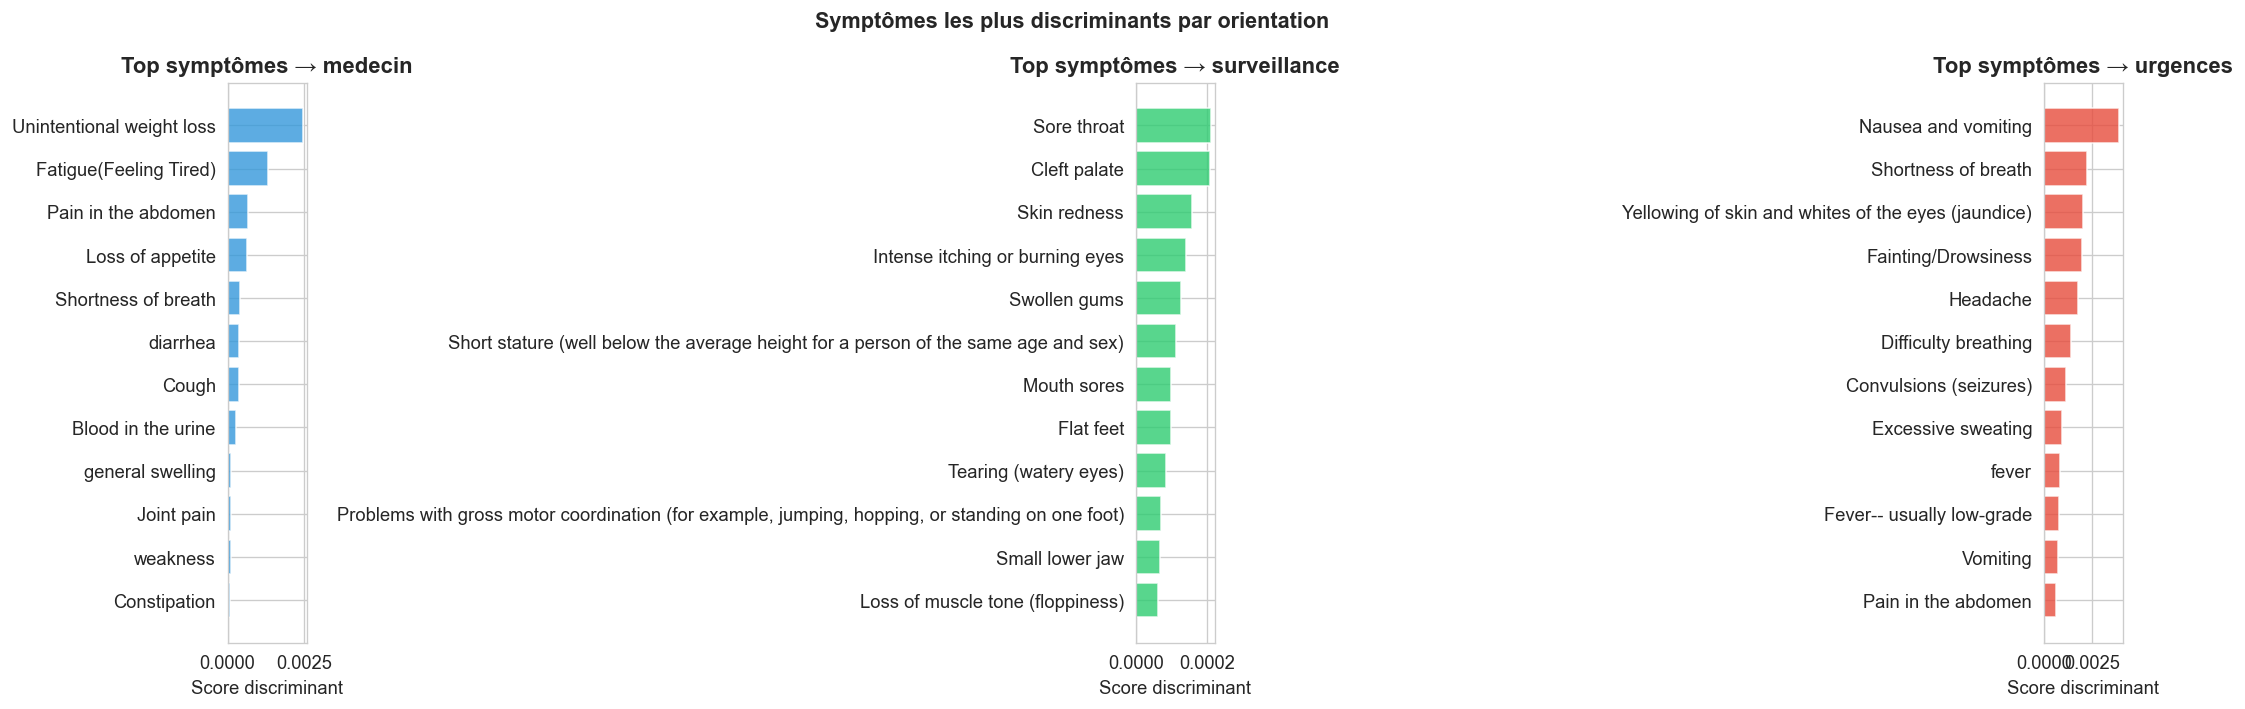

In [25]:
# Importance par orientation (analyse per-class)
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

for ax, (class_idx, orient) in zip(axes, enumerate(le.classes_)):
    # Calculer l'importance spécifique à chaque classe
    # via la différence de fréquence pondérée
    mask_class = y_train == class_idx
    freq_class  = X_train[mask_class].mean(axis=0)
    freq_other  = X_train[~mask_class].mean(axis=0)
    class_importance = (freq_class - freq_other) * importances

    top_class_idx  = np.argsort(class_importance)[::-1][:12]
    top_class_feat = [symptom_cols[i] for i in top_class_idx]
    top_class_vals = class_importance[top_class_idx]

    ax.barh(top_class_feat[::-1], top_class_vals[::-1],
            color=COLORS[orient], alpha=0.8)
    ax.set_title(f'Top symptômes → {orient}', fontweight='bold')
    ax.set_xlabel('Score discriminant')

plt.suptitle('Symptômes les plus discriminants par orientation', fontweight='bold', fontsize=13)
plt.tight_layout()
plt.show()

## 12. Sauvegarde & Test final

In [26]:
# Sauvegarde
joblib.dump(rf, f'{MODELS_PATH}orientation_model2.joblib')
joblib.dump(symptom_cols, f'{MODELS_PATH}symptom_cols2.joblib')

report = {
    'best_model'  : 'RandomForest',
    'accuracy'    : round(float(accuracy), 4),
    'cv_score'    : round(float(cv_scores.mean()), 4),
    'cv_std'      : round(float(cv_scores.std()), 4),
    'classes'     : le.classes_.tolist(),
    'n_features'  : int(X.shape[1]),
    'n_train'     : int(X_train.shape[0]),
    'n_test'      : int(X_test.shape[0]),
    'n_diseases'  : int(df['Prognosis'].nunique()),
    'n_estimators': 200,
    'max_depth'   : 20,
    'high_confidence_pct': round(float(high_conf/len(max_probas)*100), 2)
}

with open(f'{MODELS_PATH}evaluation_report.json', 'w') as f:
    json.dump(report, f, indent=2)

print('✅ Fichiers sauvegardés :')
print(f'   {MODELS_PATH}orientation_model.joblib')
print(f'   {MODELS_PATH}label_encoder.joblib')
print(f'   {MODELS_PATH}symptom_cols.joblib')
print(f'   {MODELS_PATH}evaluation_report.json')
print()
print('=== Résumé final ===')
for k, v in report.items():
    print(f'   {k:30} : {v}')

✅ Fichiers sauvegardés :
   ../models/orientation_model.joblib
   ../models/label_encoder.joblib
   ../models/symptom_cols.joblib
   ../models/evaluation_report.json

=== Résumé final ===
   best_model                     : RandomForest
   accuracy                       : 0.6398
   cv_score                       : 0.6559
   cv_std                         : 0.0241
   classes                        : ['medecin', 'surveillance', 'urgences']
   n_features                     : 1326
   n_train                        : 644
   n_test                         : 161
   n_diseases                     : 391
   n_estimators                   : 200
   max_depth                      : 20
   high_confidence_pct            : 1.86


In [27]:
# Test de prédiction finale
def predict_orientation(selected_symptoms: list) -> dict:
    vector = np.zeros(len(symptom_cols))
    for i, col in enumerate(symptom_cols):
        if col.lower() in [s.lower() for s in selected_symptoms]:
            vector[i] = 1

    pred   = rf.predict([vector])[0]
    proba  = rf.predict_proba([vector])[0]
    orient = le.inverse_transform([pred])[0]
    conf   = round(float(proba.max()) * 100, 1)

    return {
        'orientation' : orient,
        'confidence'  : conf,
        'probabilities': dict(zip(le.classes_, proba.round(3))),
        'message'     : {
            'urgences'    : '🚨 Appelez le 15 ou rendez-vous aux urgences immédiatement.',
            'medecin'     : '👨‍⚕️ Consultez un médecin dans les 24-48h.',
            'surveillance': '🏠 Surveillez vos symptômes à domicile.'
        }[orient]
    }

test_cases = [
    (['chest pain', 'sweating', 'shortness of breath', 'vomiting'],   'urgences'),
    (['high fever', 'cough', 'fatigue', 'body ache', 'headache'],      'medecin'),
    (['itching', 'skin rash', 'mild fever'],                           'surveillance'),
    (['loss of appetite', 'nausea', 'abdominal pain', 'yellowish skin'], 'medecin'),
]

print('🧪 Tests de prédiction :')
print('─' * 70)
correct = 0
for symptoms, expected in test_cases:
    result = predict_orientation(symptoms)
    ok     = result['orientation'] == expected
    correct += ok
    status = '✅' if ok else '⚠️'
    print(f"{status} Orientation : {result['orientation']:15} (confiance : {result['confidence']}%)")
    print(f"   Attendu    : {expected}")
    print(f"   Symptômes  : {', '.join(symptoms)}")
    print(f"   Proba      : {result['probabilities']}")
    print(f"   Message    : {result['message']}")
    print()

print(f'Score sur cas de test : {correct}/{len(test_cases)} ({correct/len(test_cases)*100:.0f}%)')

🧪 Tests de prédiction :
──────────────────────────────────────────────────────────────────────
✅ Orientation : urgences        (confiance : 40.6%)
   Attendu    : urgences
   Symptômes  : chest pain, sweating, shortness of breath, vomiting
   Proba      : {'medecin': np.float64(0.404), 'surveillance': np.float64(0.189), 'urgences': np.float64(0.406)}
   Message    : 🚨 Appelez le 15 ou rendez-vous aux urgences immédiatement.

✅ Orientation : medecin         (confiance : 37.0%)
   Attendu    : medecin
   Symptômes  : high fever, cough, fatigue, body ache, headache
   Proba      : {'medecin': np.float64(0.37), 'surveillance': np.float64(0.36), 'urgences': np.float64(0.269)}
   Message    : 👨‍⚕️ Consultez un médecin dans les 24-48h.

✅ Orientation : surveillance    (confiance : 44.5%)
   Attendu    : surveillance
   Symptômes  : itching, skin rash, mild fever
   Proba      : {'medecin': np.float64(0.36), 'surveillance': np.float64(0.445), 'urgences': np.float64(0.195)}
   Message    : 🏠 Su